#  Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation

###  Makale Hakkında
**Kaynak:** Saxena, A., Goebel, K., Simon, D., & Eklund, N. (NASA Ames & Glenn Research Centers, GE Global Research)
**Yıl:** 2008
**Bağlam:** PHM’08 (Prognostics and Health Management) Veri Yarışması
**Amaç:** Uçak gaz türbin motorlarındaki modüller için **hasar yayılımını (damage propagation)** modellemek ve **kalan kullanım ömrü (Remaining Useful Life - RUL)** tahmini için veri oluşturmak.

---

##  Genel Konsept

###  Problemin Tanımı
- Gerçek "run-to-failure" (arızaya kadar çalışma) verileri genellikle az veya gizli tutulduğu için, **sanal (simüle edilmiş)** bir veri seti oluşturulmuştur.
- Hedef: Verilen sensör verilerini kullanarak motorun kalan ömrünü tahmin etmektir.

---

##  Kullanılan Model: **C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)**

**C-MAPSS** NASA tarafından geliştirilmiş bir **turbofan motor simülasyon aracıdır.**

### Özellikler:
- MATLAB®/Simulink® tabanlıdır.
- Gerçek bir **90,000 lb thrust class** motoru simüle eder.
- **Girdi Parametreleri (14 adet):**
  - Yakıt akışı (`Wf`)
  - Fan, LPC, HPC, HPT, LPT modüllerinin **akış (flow)** ve **verimlilik (efficiency)** değişkenleri
- **Çıktılar (21 sensör verisi):**
  - `T2`, `T24`, `T30`, `T50`, `P2`, `P15`, `P30`, `Nf`, `Nc`, `epr`, `phi`, `NRf`, `NRc`, `BPR`, `farB`, `htBleed`, `Nf_dmd`, `PCNfR_dmd`, `W31`, `W32`

---

##  Hasar (Degradasyon) Modelleme Yaklaşımı

### 1. **Fiziksel Model Dayanakları**
- Üç klasik modelden yararlanılmıştır:
  - **Arrhenius Modeli:** Kimyasal/termal süreçler için
  - **Coffin-Manson Modeli:** Mekanik çatlak büyümesi için
  - **Eyring Modeli:** Çok stresli durumlar için
- Bu modellerin ortak özelliği: **Hasar artışının üstel (exponential) davranış göstermesidir.**

### 2. **Uygulanan Genel Denklem**
Sağlık indeksinin zamana bağlı değişimi şu şekilde modellenmiştir:

\[
h(t) = 1 - e^{(a + b t)}
\]

ve motorun **akış (f)** ve **verimlilik (e)** bileşenleri için:
\[
e(t) = 1 - A_e e^{b_e t}, \quad f(t) = 1 - A_f e^{b_f t}
\]

Bu iki değer motorun **genel sağlık indeksini (Health Index)** belirler:
\[
H(t) = \min(m_{Fan}, m_{HPC}, m_{HPT}, m_{EGT})
\]

---

##  Uygulama Senaryosu

- Her motor farklı uçuş koşullarında (irtifa, Mach sayısı, throttle açısı) çalıştırılmıştır.
- Motor verimliliği ve akışı, **yavaş yavaş azalarak** arızaya ulaşır.
- **Anlık arızalar yoktur**, ancak “between-flight maintenance” etkisi **gürültü (noise)** olarak modele dahil edilmiştir.

### Gürültü (Noise) Türleri:
- **Üretim farkları**
- **Proses gürültüsü**
- **Sensör gürültüsü**

Veri gerçekçi olması için karışık (mixture) dağılımlar kullanılmıştır.

---

##  Veri Seti (Dataset) Özeti

| Özellik | Açıklama |
|----------|-----------|
| **Simülasyon Aracı** | C-MAPSS |
| **Degradasyon Modülü** | HPC (High Pressure Compressor) |
| **Sensör Sayısı** | 21 (Tablo 2’de listelenmiştir) |
| **Toplam Motorlar (UUTs)** | Birden fazla bağımsız motor |
| **Veri Türü** | Zaman serisi (her satır = bir uçuş döngüsü) |
| **Çıktı (Label)** | RUL (Remaining Useful Life) |
| **Noise** | Gaussian + Mixture gürültüsü |
| **Sağlık Eşiği (failure criterion)** | Health Index = 0 |
| **Kullanım Alanı** | PHM (Prognostics and Health Management) RUL tahmini |

---

##  Veri Seti Bölünmesi

| Set | Kapsam | Özellik |
|------|--------|----------|
| **Train** | Tam “run-to-failure” verileri | Sağlık 1 → 0 arası |
| **Test** | Kısmen kırpılmış | Failure’dan önce durur |
| **Validation** | Farklı RUL aralıkları (6–190 cycle) | Dayanıklılık testi için |

---

##  Performans Değerlendirmesi (Scoring)

Tahmin edilen RUL (`RUL̂`) ile gerçek RUL (`RULt`) arasındaki fark:
\[
d = RUL̂ - RUL_t
\]

Asimetrik hata fonksiyonu:
\[
s = \sum
\begin{cases}
e^{-\frac{d}{a_1}} - 1, & \text{if } d < 0\\
e^{\frac{d}{a_2}} - 1, & \text{if } d \ge 0
\end{cases}
\]
Burada:
- **a₁ = 10**, **a₂ = 13**
- **Geç tahminler (late predictions)** erken tahminlerden **daha fazla cezalandırılır.**

---

##  Anahtar Terimler

- **Prognostics:** Kalan kullanım ömrünün (RUL) tahmini
- **Health Index:** Motorun anlık sağlığını ifade eden birleşik metrik
- **Damage Propagation:** Arıza belirtilerinin zamanla büyümesi
- **Run-to-Failure Simulation:** Motorun tamamen arızaya ulaşana kadar simülasyonu
- **C-MAPSS:** NASA tarafından geliştirilen açık kaynak motor simülasyon modeli

---


In [1]:
import datetime
print(f"Last updated: {datetime.datetime.now()}")

Last updated: 2025-10-13 17:25:10.159000


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import glob
import seaborn as sns
import math


In [9]:
#making columns
columns = [
    "unit_number",
    "time_in_cycles",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3",
]

# sensor measurements 1–26
columns += [f"sensor_measurement_{i}" for i in range(1, 27)]


In [13]:
#test
test_df =  pd.read_csv("data/train_FD001.txt",sep=' ',index_col=False,names=columns)
test_df

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,sensor_measurement_22,sensor_measurement_23,sensor_measurement_24,sensor_measurement_25,sensor_measurement_26
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,392,2388,100.0,39.06,23.4190,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,392,2388,100.0,39.00,23.4236,NaN,NaN,NaN,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,390,2388,100.0,38.95,23.3442,NaN,NaN,NaN,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,392,2388,100.0,38.88,23.3739,NaN,NaN,NaN,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,393,2388,100.0,38.90,23.4044,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,397,2388,100.0,38.49,22.9735,NaN,NaN,NaN,NaN,NaN
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,395,2388,100.0,38.30,23.1594,NaN,NaN,NaN,NaN,NaN
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,398,2388,100.0,38.44,22.9333,NaN,NaN,NaN,NaN,NaN
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,395,2388,100.0,38.29,23.0640,NaN,NaN,NaN,NaN,NaN


In [25]:
def process_text(path,kind):
    fname=path.removeprefix("data/")
    fname=path.removesuffix(".txt")
    if (kind == "train"):
        df= pd.read_csv(filepath_or_buffer=path,sep=' ',index_col=False,names=columns)
        print(fname)
        df.to_csv(f"{fname}.csv",index=False)
    else:
        df=pd.read_csv(filepath_or_buffer=path,sep=' ',index_col=False,names=columns)
        print(fname)
        df.to_csv(f"{fname}.csv",index=False)



In [26]:
process_text(path="data/train_FD001.txt",kind="train")

data/train_FD001


In [28]:
train_files = glob.glob("data/train_FD*.txt")

for file in train_files:
    process_text(path=file, kind="train")


test_files = glob.glob("data/test_FD*.txt")

for file in test_files:
    process_text(path=file, kind="test")



data\train_FD001
data\train_FD002
data\train_FD003
data\train_FD004
data\test_FD001
data\test_FD002
data\test_FD003
data\test_FD004


In [7]:
train_1= pd.read_csv("data/train_FD001.csv")
train_1

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,sensor_measurement_22,sensor_measurement_23,sensor_measurement_24,sensor_measurement_25,sensor_measurement_26
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,392,2388,100.0,39.06,23.4190,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,392,2388,100.0,39.00,23.4236,NaN,NaN,NaN,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,390,2388,100.0,38.95,23.3442,NaN,NaN,NaN,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,392,2388,100.0,38.88,23.3739,NaN,NaN,NaN,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,393,2388,100.0,38.90,23.4044,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,397,2388,100.0,38.49,22.9735,NaN,NaN,NaN,NaN,NaN
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,395,2388,100.0,38.30,23.1594,NaN,NaN,NaN,NaN,NaN
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,398,2388,100.0,38.44,22.9333,NaN,NaN,NaN,NaN,NaN
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,395,2388,100.0,38.29,23.0640,NaN,NaN,NaN,NaN,NaN


In [8]:
train_1.drop(columns=["sensor_measurement_22","sensor_measurement_23","sensor_measurement_24","sensor_measurement_25","sensor_measurement_26"],inplace=True)
train_1

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [11]:
rul_1 = pd.DataFrame(train_1.groupby('unit_number')['time_in_cycles'].max()).reset_index()
rul_1.columns = ['unit_number', 'max']

rul_train_1 = train_1.merge(rul_1, on=['unit_number'], how='left')
rul_train_1['RUL'] = rul_train_1['max'] - rul_train_1['time_in_cycles']
rul_train_1.drop(['max'], axis=1, inplace=True)

In [12]:
rul_train_1.groupby('unit_number')['time_in_cycles'].describe() # her motorun failrun olduğu cycleı buluyoruz aslında burda

,count,mean,std,min,25%,50%,75%,max
unit_number,,,,,,,,
1,192.0,96.5,55.569776,1.0,48.75,96.5,144.25,192.0
2,287.0,144.0,82.993976,1.0,72.50,144.0,215.50,287.0
3,179.0,90.0,51.816986,1.0,45.50,90.0,134.50,179.0
4,189.0,95.0,54.703748,1.0,48.00,95.0,142.00,189.0
5,269.0,135.0,77.797815,1.0,68.00,135.0,202.00,269.0
...,...,...,...,...,...,...,...,...
96,336.0,168.5,97.139076,1.0,84.75,168.5,252.25,336.0
97,202.0,101.5,58.456537,1.0,51.25,101.5,151.75,202.0
98,156.0,78.5,45.177428,1.0,39.75,78.5,117.25,156.0


In [13]:
rul_train_1.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_in_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
operational_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
operational_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
operational_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_measurement_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_measurement_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_measurement_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_measurement_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_measurement_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [16]:
rul_train_1

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


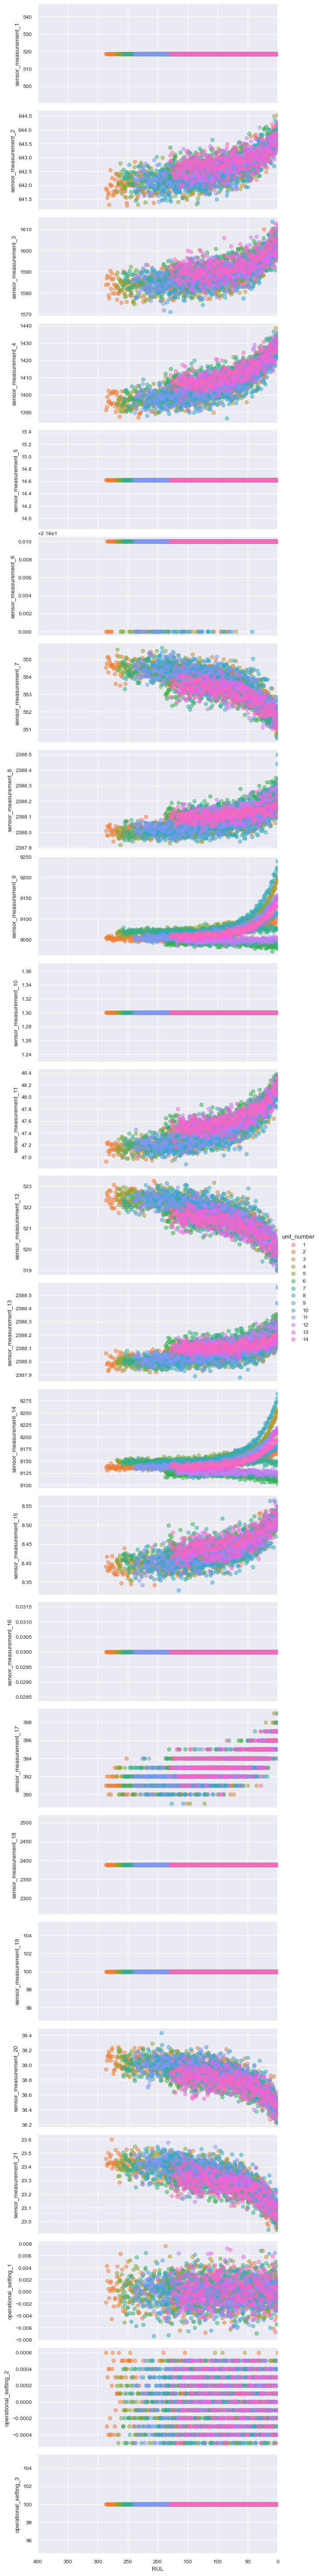

In [27]:
#RUL verileri azaldıkça sensörler nasıl gözküküyor
sensor_columns=[]
op_columns = []
sensor_columns += [f"sensor_measurement_{i}" for i in range(1, 22)]
op_columns=[f"operational_setting_{i}" for i in range (1,4)]
explore = sns.PairGrid(data=rul_train_1.query('unit_number < 15') ,
                 x_vars=["RUL"],
                 y_vars=sensor_columns + op_columns,
                 hue="unit_number", aspect=2.5)
explore = explore.map(plt.scatter, alpha=0.5)
explore = explore.set(xlim=(400,0))
explore = explore.add_legend()

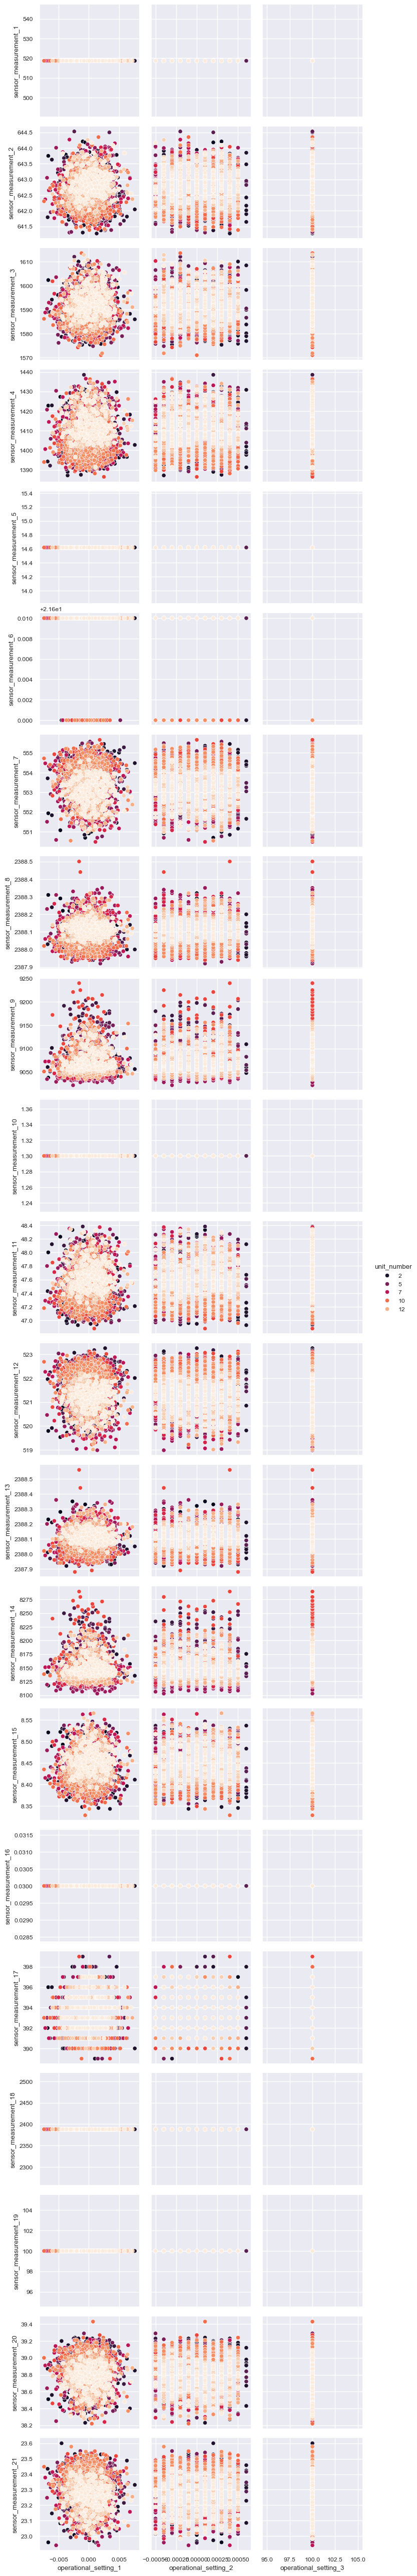

In [50]:
pair_plot = sns.pairplot(data=rul_train_1.query("unit_number < 15"),hue="unit_number",x_vars=op_columns,y_vars=sensor_columns,aspect=1,palette="rocket")

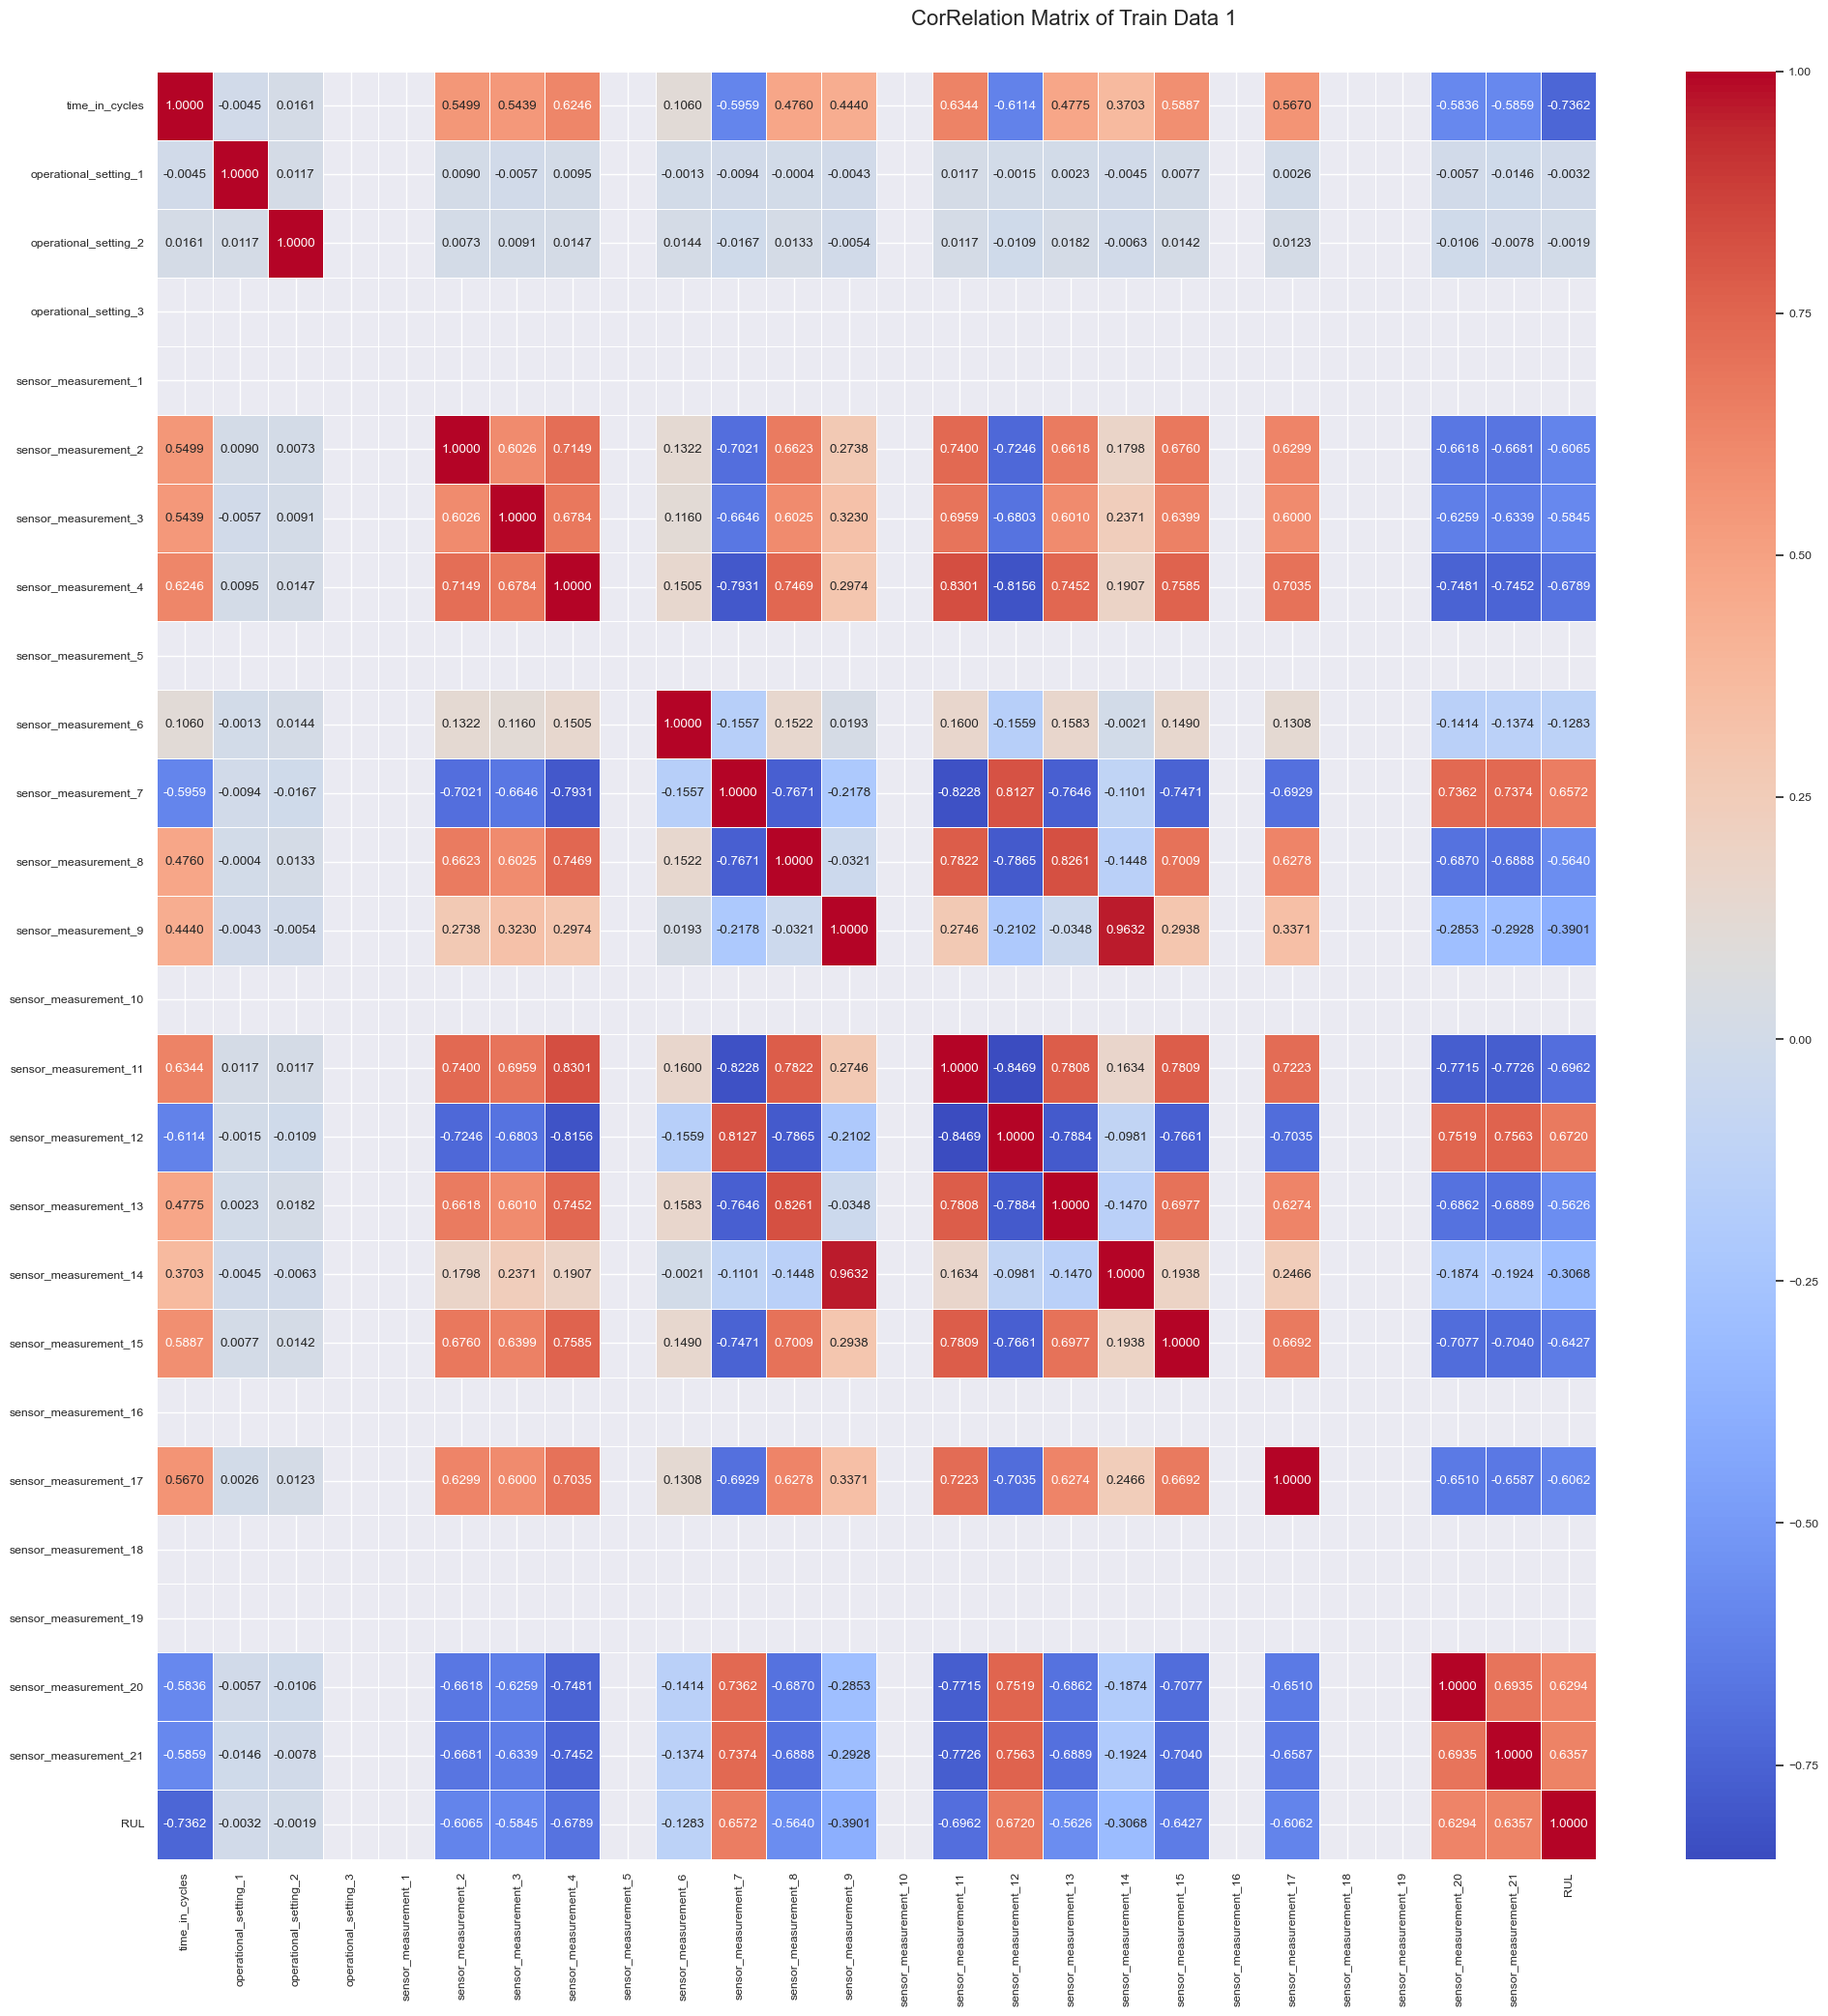

In [48]:
co_mat=rul_train_1.drop(columns=["unit_number"]).corr(numeric_only=True)
plt.figure(figsize=(24,24))
sns.heatmap(data=co_mat,cmap="coolwarm",xticklabels=True,yticklabels=True,cbar=True,annot=True,fmt=".4f",linewidths=.5)
plt.figtext(.45,0.9,"CorRelation Matrix of Train Data 1",fontsize=16)
plt.xticks(rotation=90)
plt.show()
